In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.options.display.max_columns = 50

In [6]:
df = pd.read_excel("LungReferralsJuly-Sept2025.xlsx")

In [7]:
df.columns

Index(['Nhs_Number', 'CareId', 'Patient_Name', 'DOB', 'Age',
       'Referring_Specialty', 'OPReferralSourceCode', 'OPReferralSource',
       'Registered_GP_Practice', 'GP_Practice_Code', 'GP_Address',
       'ResponsibleCCG', 'Legacy_CCG_Code', 'Legacy_CCG_Name', 'Consultant',
       'Cancer_Site', 'CancerType', 'Subtype', 'CancerStatus',
       'ReferralReceivedDate', 'ReferralReceivedMonth', 'PriorityType',
       'FirstSeenDate', 'DTT_DecisionToTreatDate', 'DTT_TreatmentDate',
       'Cancer Diagnosis', 'Total Count', 'Referral_In_The_Last_Two_Years',
       'ReferralWeek_No', 'WeekEnding_Date', 'Referral_In_The_Last_Year'],
      dtype='object')

In [8]:
df = df.drop(columns=['Nhs_Number', 'CareId', 'Patient_Name', 'DOB'])

In [9]:
df.head()

,Age,Referring_Specialty,OPReferralSourceCode,OPReferralSource,Registered_GP_Practice,GP_Practice_Code,GP_Address,ResponsibleCCG,Legacy_CCG_Code,Legacy_CCG_Name,Consultant,Cancer_Site,CancerType,Subtype,CancerStatus,ReferralReceivedDate,ReferralReceivedMonth,PriorityType,FirstSeenDate,DTT_DecisionToTreatDate,DTT_TreatmentDate,Cancer Diagnosis,Total Count,Referral_In_The_Last_Two_Years,ReferralWeek_No,WeekEnding_Date,Referral_In_The_Last_Year
0,54,NaN,5,"Consultant, other than in an Emergency Care De...",F84686,F84686,"THE SURGERY, 62 CRANWICH ROAD, LONDON, , N16 5JF",NHS North East London CCG,07T,NHS CITY AND HACKNEY CCG,Unknown Consultant,Lung,Suspected lung cancer,Thoracic,No new cancer diagnosis identified by the Heal...,2025-07-31,2025-07-01,Urgent,2025-08-19,NaT,NaT,0,1,Y,31,2025-08-03,Y
1,56,Respiratory Medicine,3,General Medical Practitioner,F84117,F84117,"QUEENSBRIDGE GROUP PRACT., 24 HOLLY STREET, LO...",NHS North East London CCG,07T,NHS CITY AND HACKNEY CCG,BHOWMIK,Lung,Suspected lung cancer,NaN,No new cancer diagnosis identified by the Heal...,2025-07-31,2025-07-01,Two Week Wait,2025-08-05,NaT,NaT,0,1,Y,31,2025-08-03,Y
2,75,Respiratory Medicine,3,General Medical Practitioner,F84105,F84105,"THE LEA SURGERY, ALFRED HEALTH CENTRE, 186 HOM...",NHS North East London CCG,07T,NHS CITY AND HACKNEY CCG,BHOWMIK,Lung,Suspected lung cancer,NaN,No new cancer diagnosis identified by the Heal...,2025-07-31,2025-07-01,Two Week Wait,2025-08-08,NaT,NaT,0,1,Y,31,2025-08-03,Y
3,40,Respiratory Medicine,3,General Medical Practitioner,F84036,F84036,"CEDAR PRACTICE, JOHN SCOTT HEALTH CENTRE, WOOD...",NHS North East London CCG,07T,NHS CITY AND HACKNEY CCG,BHOWMIK,Lung,Suspected lung cancer,NaN,No new cancer diagnosis identified by the Heal...,2025-07-30,2025-07-01,Two Week Wait,2025-08-01,NaT,NaT,0,1,Y,31,2025-08-03,Y
4,50,Respiratory Medicine,3,General Medical Practitioner,F84105,F84105,"THE LEA SURGERY, ALFRED HEALTH CENTRE, 186 HOM...",NHS North East London CCG,07T,NHS CITY AND HACKNEY CCG,BHOWMIK,Lung,Suspected lung cancer,NaN,No new cancer diagnosis identified by the Heal...,2025-07-30,2025-07-01,Two Week Wait,2025-08-05,NaT,NaT,0,1,Y,31,2025-08-03,Y


In [13]:
df = df.copy()
df['ReferralReceivedDate'] = pd.to_datetime(df['ReferralReceivedDate'])
df['FirstSeenDate'] = pd.to_datetime(df['FirstSeenDate'])
df['TurnaroundTime'] = df['FirstSeenDate'] - df['ReferralReceivedDate']

In [26]:
df['TAT_days'] = (
    df['TurnaroundTime'].dropna().astype(str)
    .str.replace(' days', '', regex=False)
    .astype(int)
)

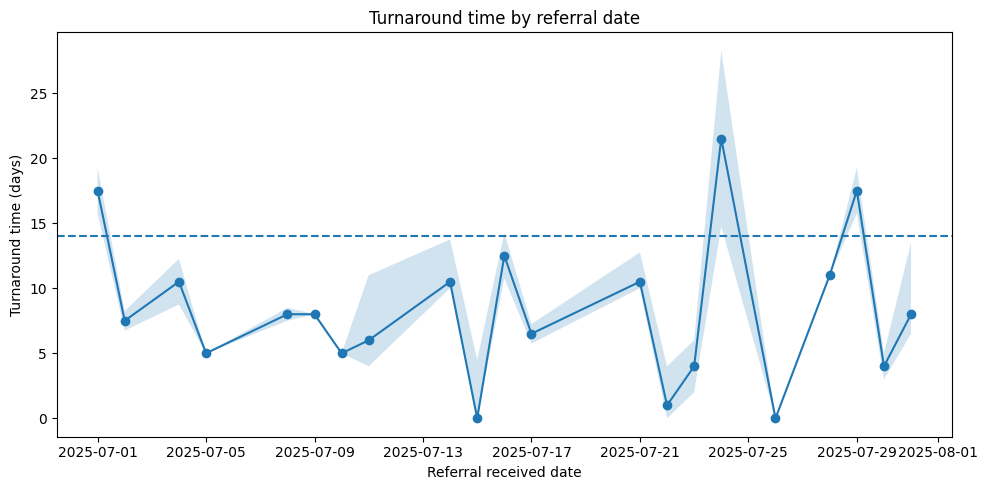

In [27]:
daily = (
    df.groupby('ReferralReceivedDate')['TAT_days']
      .agg(['median', 'quantile'])
)

q25 = df.groupby('ReferralReceivedDate')['TAT_days'].quantile(0.25)
q75 = df.groupby('ReferralReceivedDate')['TAT_days'].quantile(0.75)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(daily.index, daily['median'], marker='o')
plt.fill_between(daily.index, q25, q75, alpha=0.2)
plt.axhline(14, linestyle='--')  # e.g. 2WW target
plt.ylabel('Turnaround time (days)')
plt.xlabel('Referral received date')
plt.title('Turnaround time by referral date')
plt.tight_layout()
plt.show()


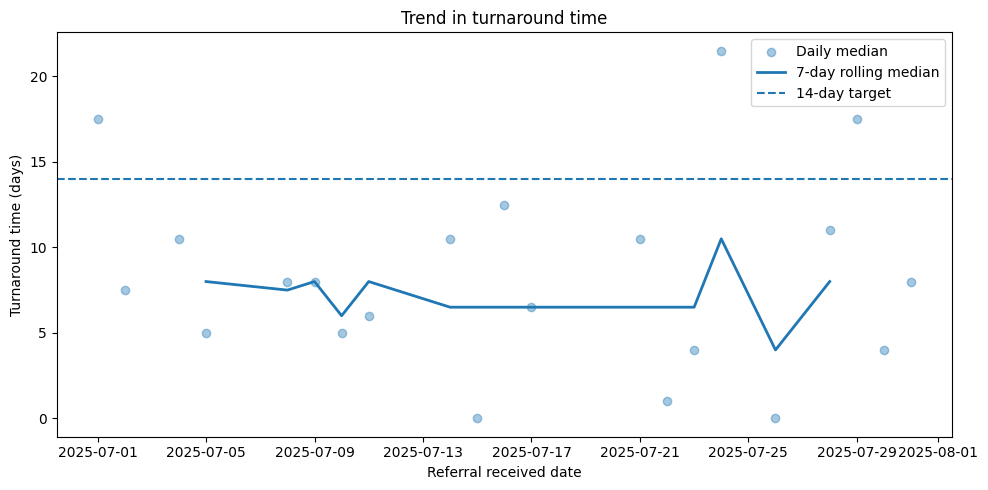

In [30]:
import matplotlib.pyplot as plt

daily = (
    df.groupby('ReferralReceivedDate')['TAT_days']
      .median()
      .sort_index()
)

rolling = daily.rolling(window=7, center=True).median()  # 7-day smoothing

plt.figure(figsize=(10,5))
plt.scatter(daily.index, daily.values, alpha=0.4, label='Daily median')
plt.plot(rolling.index, rolling.values, linewidth=2, label='7-day rolling median')
plt.axhline(14, linestyle='--', label='14-day target')

plt.ylabel('Turnaround time (days)')
plt.xlabel('Referral received date')
plt.title('Trend in turnaround time')
plt.legend()
plt.tight_layout()

plt.savefig(
    'turnaround_time_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()
